# Notebook 06 — XGBoost (Stacked Dataset)
## ENGG2112 Project MODR

Third model in the comparison study. Same dataset (357 rows: flu + COVID + RSV), same CV strategy, same feature set as Notebooks 04–05.

### Why XGBoost
Gradient boosting often outperforms Random Forest on small tabular datasets because it:
1. Sequentially corrects residual errors (lower bias than bagging)
2. Has built-in L1/L2 regularisation (`alpha`, `lambda`)
3. Learns a more compact representation — typically fewer trees needed than RF

### Hypothesis
XGBoost reaches PR-AUC ≥ 0.51 (matching or beating RF's 0.506).

### Structure
1. Setup
2. Load data + build feature matrix
3. Hyperparameter tuning (GridSearchCV)
4. Out-of-fold predictions
5. Performance metrics
6. Calibration
7. Feature importance (gain + permutation)
8. Per-disease breakdown
9. Save model + metrics
10. **Multi-model comparison: LR vs RF vs XGBoost**

## 1. Setup &amp; Import Required Libraries

In [13]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
import xgboost as xgb

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 13, 'axes.labelsize': 11,
                     'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_style('whitegrid')

## 2. Load and Prepare Data

In [14]:
# Load stacked dataset
master = pd.read_csv(PROCESSED_DIR / 'master_stacked.csv', dtype={'fips': str, 'state_fips': str})

# Load selected features
with open(PROCESSED_DIR / 'selected_features.json') as f:
    fc = json.load(f)
DEMO = fc['demographic']
DISEASE_DUMMIES = fc['disease_dummies']
STATE_DUMMIES = fc['state_dummies']

print(f'Stacked dataset shape: {master.shape}')
print(f'Demographic features ({len(DEMO)}): {DEMO}')
print(f'Disease dummies: {DISEASE_DUMMIES}')
print(f'State dummies: {STATE_DUMMIES}')
print(f'Outbreak rate: {master["outbreak"].mean():.1%}')

Stacked dataset shape: (357, 40)
Demographic features (5): ['pct_foreign_born', 'pop_density_per_sqmi', 'avg_household_size', 'public_transport_pct', 'pct_elderly']
Disease dummies: ['disease_FLU', 'disease_RSV']
State dummies: ['state_DE', 'state_NY', 'state_PA']
Outbreak rate: 26.1%


## 3. Build Feature Matrix

In [15]:
# Build feature matrix (same as logistic regression)
disease_X = pd.get_dummies(master['disease'], prefix='disease', drop_first=True).astype(float)
state_X = pd.get_dummies(master['state'], prefix='state', drop_first=True).astype(float)

scaler = StandardScaler()
demo_X = pd.DataFrame(scaler.fit_transform(master[DEMO]), columns=DEMO, index=master.index)

X = pd.concat([demo_X, disease_X[DISEASE_DUMMIES], state_X[STATE_DUMMIES]], axis=1)
y = master['outbreak'].astype(int).values
groups = master['fips'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {list(X.columns)}')
print(f'Outcome distribution: {np.bincount(y)} ({y.sum()} outbreaks, {(1-y).sum()} non-outbreaks)')
print(f'Unique counties (groups): {len(set(groups))}')

Feature matrix shape: (357, 10)
Features: ['pct_foreign_born', 'pop_density_per_sqmi', 'avg_household_size', 'public_transport_pct', 'pct_elderly', 'disease_FLU', 'disease_RSV', 'state_DE', 'state_NY', 'state_PA']
Outcome distribution: [264  93] (93 outbreaks, 264 non-outbreaks)
Unique counties (groups): 149


## 4. Hyperparameter Tuning via RandomizedSearchCV

XGBoost's key levers:
- `n_estimators` + `learning_rate` together control capacity (more rounds + lower LR = better generalisation)
- `max_depth`: tree depth — 3–5 works well on small datasets; deeper risks overfitting
- `subsample` / `colsample_bytree`: stochastic sampling reduces variance
- `min_child_weight`: minimum sum of instance weight in a child — higher values prune more aggressively
- `gamma`: minimum loss reduction to make a split — regularises tree growth

`scale_pos_weight` is fixed to the negative/positive ratio — it's a data property, not a hyperparameter to tune.

`RandomizedSearchCV` with 60 iterations samples a broader grid than an exhaustive GridSearch, giving better coverage of the hyperparameter space at the same compute cost.

In [16]:
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedGroupKFold(n_splits=5)

n_neg = int((y == 0).sum())
n_pos = int((y == 1).sum())
scale_pos = round(n_neg / n_pos, 2)
print(f'Class distribution: {n_pos} outbreak / {n_neg} non-outbreak → scale_pos_weight = {scale_pos}')

base_xgb = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    verbosity=0,
    eval_metric='logloss',
    n_jobs=-1,
)

# Broader search space — RandomizedSearchCV samples 60 combinations
param_dist = {
    'n_estimators':     [200, 300, 400, 500, 600, 800],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 5],
    'gamma':            [0, 0.05, 0.1, 0.2, 0.3],
}

search = RandomizedSearchCV(
    base_xgb, param_distributions=param_dist,
    n_iter=60, cv=cv, scoring='average_precision',
    random_state=42, n_jobs=-1, verbose=0,
)
search.fit(X, y, groups=groups)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV PR-AUC: {search.best_score_:.3f}')

results_df = pd.DataFrame(search.cv_results_)
top5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print(f'\nTop 5 configs:')
for _, row in top5.iterrows():
    print(f'  PR-AUC = {row["mean_test_score"]:.3f} ± {row["std_test_score"]:.3f}  |  {row["params"]}')

# Alias for downstream cells
grid = search

Class distribution: 93 outbreak / 264 non-outbreak → scale_pos_weight = 2.84

Best params: {'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV PR-AUC: 0.525

Top 5 configs:
  PR-AUC = 0.525 ± 0.108  |  {'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
  PR-AUC = 0.523 ± 0.113  |  {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.05, 'colsample_bytree': 0.7}
  PR-AUC = 0.522 ± 0.093  |  {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.6}
  PR-AUC = 0.513 ± 0.096  |  {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.05, 'colsample_bytree': 0.6}
  PR-AUC = 0.513 ± 0.120  |  {'subsample': 0.8, 'n_e

## 5. Out-of-Fold Predictions

Replay the best params through `cross_val_predict` — each row is scored by a model that never saw it during training.

In [17]:
best_xgb = xgb.XGBClassifier(
    **grid.best_params_,
    scale_pos_weight=scale_pos,
    random_state=42,
    verbosity=0,
    eval_metric='logloss',
    n_jobs=-1,
)

oof_proba = cross_val_predict(best_xgb, X, y, cv=cv, method='predict_proba', groups=groups)[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

# Final model fit on full dataset (for feature importance + inference)
model = xgb.XGBClassifier(
    **grid.best_params_,
    scale_pos_weight=scale_pos,
    random_state=42,
    verbosity=0,
    eval_metric='logloss',
    n_jobs=-1,
)
model.fit(X, y)
print(f'XGBoost trained: {grid.best_params_["n_estimators"]} trees, depth {grid.best_params_["max_depth"]}')

XGBoost trained: 800 trees, depth 4


## 6. Performance Metrics

In [18]:
positive_rate = y.mean()

metrics = {
    'accuracy': accuracy_score(y, oof_pred),
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall': recall_score(y, oof_pred, zero_division=0),
    'f1': f1_score(y, oof_pred, zero_division=0),
    'roc_auc': roc_auc_score(y, oof_proba),
    'pr_auc': average_precision_score(y, oof_proba),
    'brier': brier_score_loss(y, oof_proba),
}

print('Cross-validated metrics (out-of-fold, StratifiedGroupKFold):\n')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')

print(f'\nBaselines:')
print(f'  Random PR-AUC:        {positive_rate:.3f}')
print(f'  Always-zero accuracy: {1 - positive_rate:.3f}')
print(f'\n{classification_report(y, oof_pred, target_names=["Non-outbreak", "Outbreak"])}')

Cross-validated metrics (out-of-fold, StratifiedGroupKFold):

  accuracy    : 0.711
  precision   : 0.442
  recall      : 0.409
  f1          : 0.425
  roc_auc     : 0.661
  pr_auc      : 0.506 ← HEADLINE
  brier       : 0.195

Baselines:
  Random PR-AUC:        0.261
  Always-zero accuracy: 0.739

              precision    recall  f1-score   support

Non-outbreak       0.80      0.82      0.81       264
    Outbreak       0.44      0.41      0.42        93

    accuracy                           0.71       357
   macro avg       0.62      0.61      0.62       357
weighted avg       0.70      0.71      0.71       357



## 7. Calibration — Critical for SIR Coupling

XGBoost probabilities can be over-confident. Post-hoc isotonic regression on the OOF predictions, matching the approach from Notebook 05.

Brier score:
  Uncalibrated:        0.195
  Isotonic-calibrated: 0.163
  Improvement:         +0.032


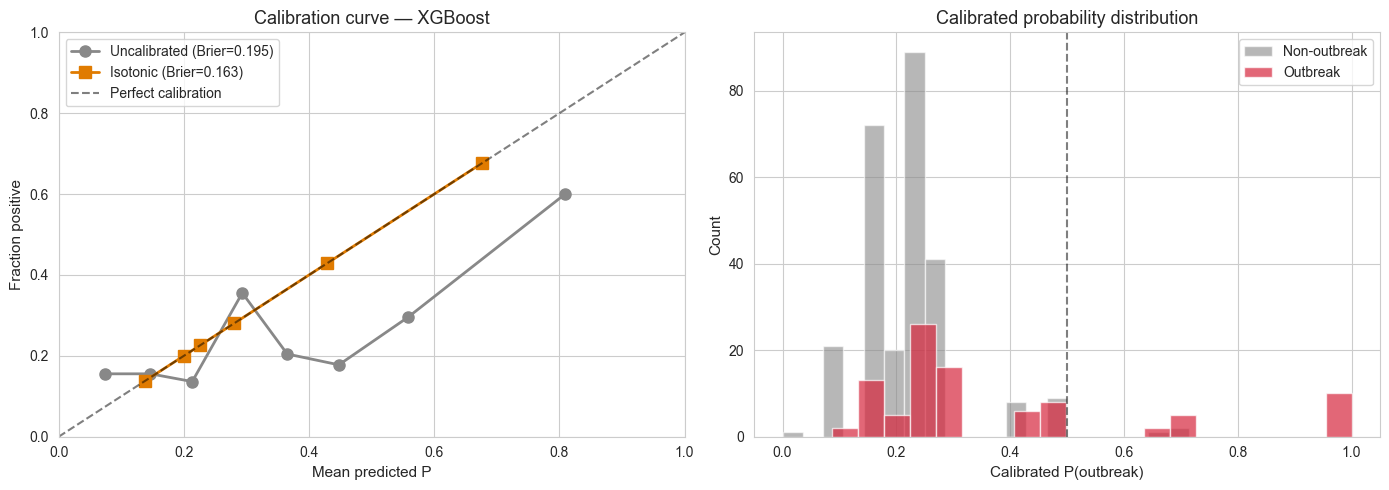

In [19]:
prob_true_uncal, prob_pred_uncal = calibration_curve(y, oof_proba, n_bins=8, strategy='quantile')
brier_uncal = metrics['brier']

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_proba, y)
calibrated_proba = iso.predict(oof_proba)

prob_true_cal, prob_pred_cal = calibration_curve(y, calibrated_proba, n_bins=8, strategy='quantile')
brier_cal = brier_score_loss(y, calibrated_proba)

print(f'Brier score:')
print(f'  Uncalibrated:        {brier_uncal:.3f}')
print(f'  Isotonic-calibrated: {brier_cal:.3f}')
print(f'  Improvement:         {brier_uncal - brier_cal:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(prob_pred_uncal, prob_true_uncal, 'o-', color='#888888', lw=2, ms=8,
        label=f'Uncalibrated (Brier={brier_uncal:.3f})')
ax.plot(prob_pred_cal, prob_true_cal, 's-', color='#E07B00', lw=2, ms=8,
        label=f'Isotonic (Brier={brier_cal:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted P'); ax.set_ylabel('Fraction positive')
ax.set_title('Calibration curve — XGBoost'); ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.hist(calibrated_proba[y == 0], bins=20, alpha=0.6, color='#888888',
        label='Non-outbreak', edgecolor='white')
ax.hist(calibrated_proba[y == 1], bins=20, alpha=0.7, color='#D7263D',
        label='Outbreak', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Calibrated P(outbreak)'); ax.set_ylabel('Count')
ax.set_title('Calibrated probability distribution'); ax.legend()

plt.tight_layout(); plt.show()

## 8. Feature Importance — Gain vs Permutation

XGBoost's built-in `feature_importances_` uses **gain** — total loss improvement across splits on each feature. We also compute **permutation importance** (same metric as Notebook 05) for a cross-model comparison.

Feature importance (sorted by permutation):

                        gain  permutation  perm_std
pct_foreign_born      0.1206       0.2043    0.0276
avg_household_size    0.1254       0.1153    0.0247
public_transport_pct  0.1046       0.0947    0.0198
pop_density_per_sqmi  0.1137       0.0802    0.0199
pct_elderly           0.0987       0.0640    0.0163
disease_FLU           0.0673       0.0169    0.0028
disease_RSV           0.0915       0.0098    0.0030
state_NY              0.1623       0.0070    0.0067
state_PA              0.1159       0.0039    0.0043
state_DE              0.0000       0.0000    0.0000


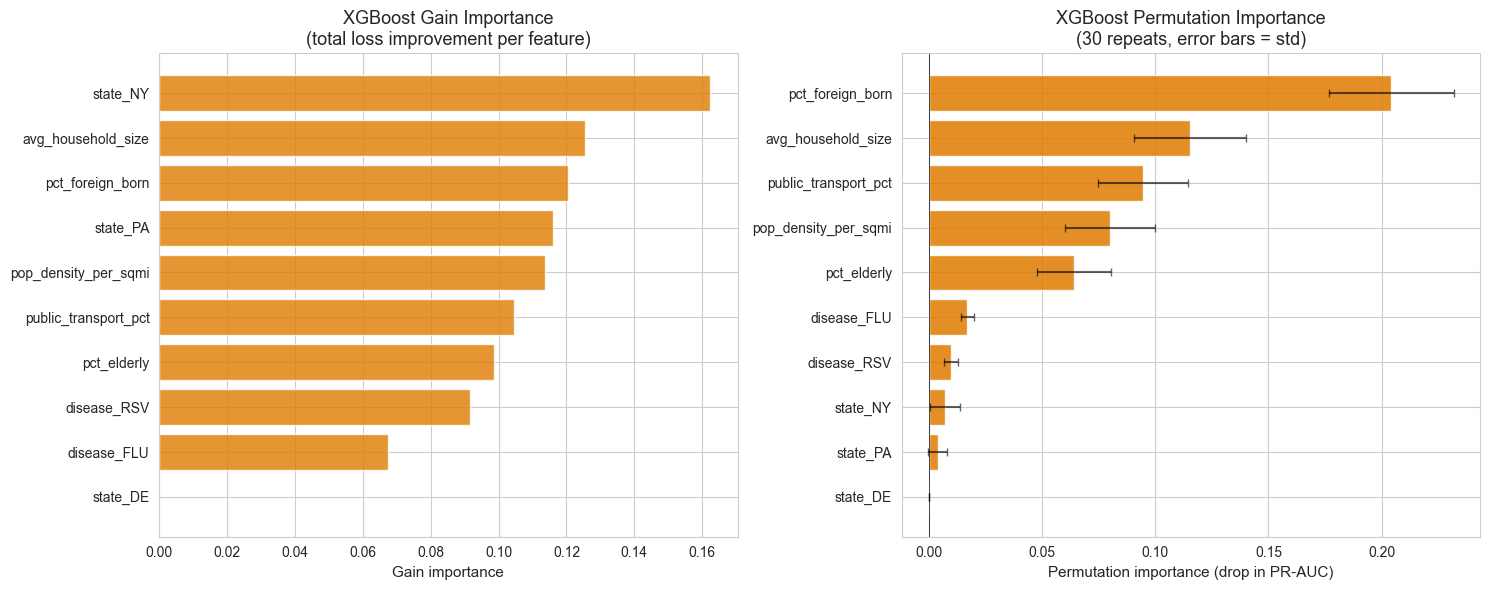

In [20]:
gain_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

perm = permutation_importance(
    model, X, y, n_repeats=30, random_state=42, n_jobs=-1, scoring='average_precision'
)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std_s = pd.Series(perm.importances_std, index=X.columns)

importance_df = pd.DataFrame({
    'gain': gain_imp,
    'permutation': perm_imp,
    'perm_std': perm_std_s,
}).sort_values('permutation', ascending=False).round(4)

print('Feature importance (sorted by permutation):\n')
print(importance_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sorted_g = gain_imp.sort_values()
ax.barh(sorted_g.index, sorted_g.values, color='#E07B00', edgecolor='white', alpha=0.8)
ax.set_xlabel('Gain importance')
ax.set_title('XGBoost Gain Importance\n(total loss improvement per feature)')

ax = axes[1]
sorted_p = perm_imp.sort_values()
sorted_std = perm_std_s.reindex(sorted_p.index)
ax.barh(sorted_p.index, sorted_p.values, xerr=sorted_std.values,
        color='#E07B00', edgecolor='white', alpha=0.85,
        error_kw={'ecolor': 'black', 'capsize': 3, 'alpha': 0.6})
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Permutation importance (drop in PR-AUC)')
ax.set_title('XGBoost Permutation Importance\n(30 repeats, error bars = std)')

plt.tight_layout(); plt.show()

## 9. Per-Disease Breakdown

In [21]:
per_pred_df = pd.DataFrame({
    'disease': master['disease'].values,
    'true': y,
    'pred': oof_pred,
    'proba': oof_proba,
    'proba_calibrated': calibrated_proba,
})

per_disease = per_pred_df.groupby('disease').apply(lambda g: pd.Series({
    'n': len(g),
    'positives': int(g['true'].sum()),
    'pr_auc': round(average_precision_score(g['true'], g['proba']), 3) if g['true'].sum() > 0 else np.nan,
    'pr_auc_calibrated': round(average_precision_score(g['true'], g['proba_calibrated']), 3) if g['true'].sum() > 0 else np.nan,
    'roc_auc': round(roc_auc_score(g['true'], g['proba']), 3) if g['true'].nunique() == 2 else np.nan,
    'accuracy': round(accuracy_score(g['true'], g['pred']), 3),
}), include_groups=False)

print('Per-disease performance (XGBoost):\n')
print(per_disease.to_string())

lr_path = MODELS_DIR / 'lr_metrics.json'
rf_path = MODELS_DIR / 'rf_metrics.json'
if lr_path.exists() and rf_path.exists():
    with open(lr_path) as f:
        lr_m_pre = json.load(f)
    with open(rf_path) as f:
        rf_m_pre = json.load(f)
    print('\n=== Per-disease PR-AUC: LR vs RF vs XGBoost ===')
    for disease in per_disease.index:
        lr_v = lr_m_pre.get('per_disease_performance', {}).get(disease, {}).get('pr_auc', np.nan)
        rf_v = rf_m_pre.get('per_disease_performance', {}).get(disease, {}).get('pr_auc', np.nan)
        xgb_v = float(per_disease.loc[disease, 'pr_auc'])
        vals = [v for v in [lr_v, rf_v, xgb_v] if not np.isnan(v)]
        best = max(vals) if vals else np.nan
        print(f'  {disease}: LR={lr_v:.3f}  RF={rf_v:.3f}  XGB={xgb_v:.3f}  [best={best:.3f}]')

Per-disease performance (XGBoost):

             n  positives  pr_auc  pr_auc_calibrated  roc_auc  accuracy
disease                                                                
COVID    140.0       36.0   0.625              0.604    0.732     0.771
FLU      141.0       37.0   0.495              0.488    0.629     0.681
RSV       76.0       20.0   0.326              0.332    0.568     0.658

=== Per-disease PR-AUC: LR vs RF vs XGBoost ===
  COVID: LR=0.554  RF=0.664  XGB=0.625  [best=0.664]
  FLU: LR=0.479  RF=0.445  XGB=0.495  [best=0.495]
  RSV: LR=0.228  RF=0.308  XGB=0.326  [best=0.326]


## 10. Multi-Model Comparison — LR vs RF vs XGBoost

All three models trained on the same 357-row stacked dataset with identical 5-fold StratifiedGroupKFold CV. First full head-to-head before Notebook 08 (which adds KNN and selects the production model).

=== MODEL COMPARISON (CV, n=357, StratifiedGroupKFold) ===

Metric           LR       RF      XGB  Winner
------------------------------------------------
PR-AUC        0.446    0.508    0.506      RF
ROC-AUC       0.610    0.651    0.661     XGB
Accuracy      0.669    0.782    0.711      RF
F1            0.372    0.381    0.425     XGB
Brier         0.231    0.175    0.195      RF

Baseline PR-AUC (random): 0.261


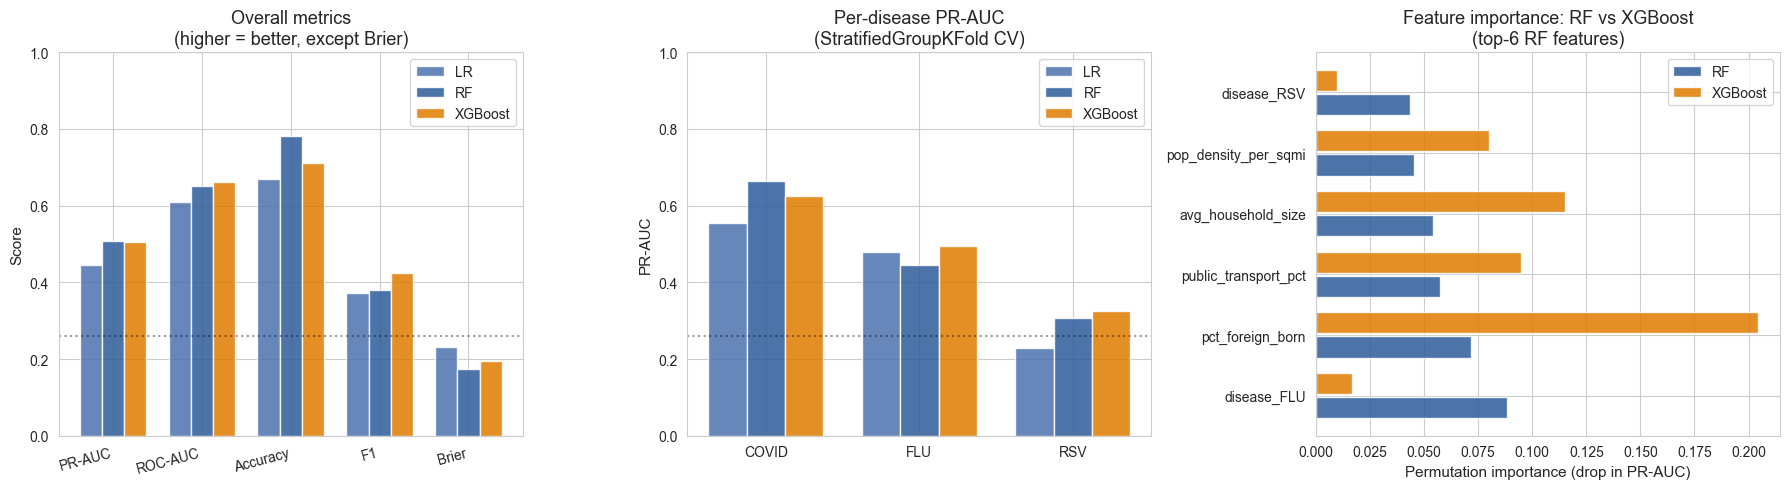

In [22]:
with open(MODELS_DIR / 'lr_metrics.json') as f:
    lr_m = json.load(f)
with open(MODELS_DIR / 'rf_metrics.json') as f:
    rf_m = json.load(f)

lr_cv = lr_m['cv_metrics']
rf_cv = rf_m['cv_metrics']
xgb_cv = metrics

# ── Summary table ──────────────────────────────────────────────────────────────
metric_defs = [
    ('pr_auc',   'PR-AUC',   True),
    ('roc_auc',  'ROC-AUC',  True),
    ('accuracy', 'Accuracy', True),
    ('f1',       'F1',       True),
    ('brier',    'Brier',    False),
]

print('=== MODEL COMPARISON (CV, n=357, StratifiedGroupKFold) ===\n')
print(f'{"Metric":<10}  {"LR":>7}  {"RF":>7}  {"XGB":>7}  {"Winner":>6}')
print('-' * 48)
for key, label, higher_better in metric_defs:
    vals = {'LR': lr_cv[key], 'RF': rf_cv[key], 'XGB': xgb_cv[key]}
    winner = (max if higher_better else min)(vals, key=vals.get)
    print(f'{label:<10}  {vals["LR"]:>7.3f}  {vals["RF"]:>7.3f}  {vals["XGB"]:>7.3f}  {winner:>6}')
print(f'\nBaseline PR-AUC (random): {lr_m["baseline_pr_auc"]:.3f}')

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
COLORS = {'LR': '#4C72B0', 'RF': '#2E5C9A', 'XGB': '#E07B00'}

# 1. Overall metrics bar chart
ax = axes[0]
display_labels = [d[1] for d in metric_defs]
x = np.arange(len(display_labels))
width = 0.25
lr_vals  = [lr_cv[k]  for k, *_ in metric_defs]
rf_vals  = [rf_cv[k]  for k, *_ in metric_defs]
xgb_vals = [xgb_cv[k] for k, *_ in metric_defs]
ax.bar(x - width, lr_vals,  width, label='LR',      color=COLORS['LR'],  alpha=0.85)
ax.bar(x,         rf_vals,  width, label='RF',      color=COLORS['RF'],  alpha=0.85)
ax.bar(x + width, xgb_vals, width, label='XGBoost', color=COLORS['XGB'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(display_labels, rotation=15, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('Overall metrics\n(higher = better, except Brier)')
ax.legend()
ax.axhline(lr_m['baseline_pr_auc'], color='black', linestyle=':', alpha=0.4,
           label='Baseline')

# 2. Per-disease PR-AUC
ax = axes[1]
diseases = ['COVID', 'FLU', 'RSV']
lr_d  = [lr_m['per_disease_performance'].get(d, {}).get('pr_auc', 0) for d in diseases]
rf_d  = [rf_m['per_disease_performance'].get(d, {}).get('pr_auc', 0) for d in diseases]
xgb_d = [float(per_disease.loc[d, 'pr_auc']) if d in per_disease.index else 0 for d in diseases]
x2 = np.arange(len(diseases))
ax.bar(x2 - width, lr_d,  width, label='LR',      color=COLORS['LR'],  alpha=0.85)
ax.bar(x2,         rf_d,  width, label='RF',       color=COLORS['RF'],  alpha=0.85)
ax.bar(x2 + width, xgb_d, width, label='XGBoost',  color=COLORS['XGB'], alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(diseases)
ax.set_ylabel('PR-AUC'); ax.set_ylim(0, 1)
ax.set_title('Per-disease PR-AUC\n(StratifiedGroupKFold CV)')
ax.legend()
ax.axhline(lr_m['baseline_pr_auc'], color='black', linestyle=':', alpha=0.4)

# 3. Feature importance: RF vs XGBoost permutation
ax = axes[2]
rf_perm = rf_m['feature_importance']['permutation']
top_feats = sorted(rf_perm, key=rf_perm.get, reverse=True)[:6]
rf_top  = [rf_perm[f] for f in top_feats]
xgb_top = [float(importance_df.loc[f, 'permutation']) if f in importance_df.index else 0
           for f in top_feats]
yp = np.arange(len(top_feats))
ax.barh(yp - 0.2, rf_top,  0.35, label='RF',      color=COLORS['RF'],  alpha=0.85)
ax.barh(yp + 0.2, xgb_top, 0.35, label='XGBoost', color=COLORS['XGB'], alpha=0.85)
ax.set_yticks(yp); ax.set_yticklabels(top_feats)
ax.set_xlabel('Permutation importance (drop in PR-AUC)')
ax.set_title('Feature importance: RF vs XGBoost\n(top-6 RF features)')
ax.legend(); ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout(); plt.show()

## 11. Save Model + Metrics

Schema matches `rf_metrics.json` exactly so Notebook 08 can load all models with the same code.

In [23]:
artifact = {
    'model': model,
    'isotonic_calibrator': iso,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'best_params': grid.best_params_,
    'scale_pos_weight': float(scale_pos),
    'metrics': metrics,
}
with open(MODELS_DIR / 'xgb_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)
print('✅ models/xgb_model.pkl')

with open(MODELS_DIR / 'xgb_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ models/xgb_scaler.pkl')

per_disease_export = {}
for disease, row in per_disease.iterrows():
    per_disease_export[disease] = {
        'n': int(row['n']),
        'positives': int(row['positives']),
        'pr_auc': float(row['pr_auc']),
        'pr_auc_calibrated': float(row['pr_auc_calibrated']),
        'roc_auc': float(row['roc_auc']) if not np.isnan(row['roc_auc']) else None,
        'accuracy': float(row['accuracy']),
    }

metrics_export = {
    'model': 'XGBoost',
    'dataset': 'master_stacked.csv',
    'n_observations': int(len(y)),
    'n_features': int(X.shape[1]),
    'positive_class_rate': float(y.mean()),
    'cv_strategy': 'StratifiedGroupKFold(n_splits=5, groups=fips)',
    'best_params': grid.best_params_,
    'scale_pos_weight': float(scale_pos),
    'cv_metrics': {k: float(v) for k, v in metrics.items()},
    'cv_metrics_calibrated': {'brier': float(brier_cal)},
    'baseline_pr_auc': float(positive_rate),
    'feature_importance': {
        'gain': {f: float(v) for f, v in gain_imp.items()},
        'permutation': {f: float(v) for f, v in perm_imp.items()},
        'permutation_std': {f: float(v) for f, v in perm_std_s.items()},
    },
    'per_disease_performance': per_disease_export,
}
with open(MODELS_DIR / 'xgb_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)
print('✅ models/xgb_metrics.json')

✅ models/xgb_model.pkl
✅ models/xgb_scaler.pkl
✅ models/xgb_metrics.json


## 12. Summary

In [24]:
print('=== NOTEBOOK 06 — XGBOOST SUMMARY ===\n')
print(f'Dataset: master_stacked.csv ({len(y)} rows: flu + COVID + RSV)')
print(f'Features: {X.shape[1]}  |  Best params: {grid.best_params_}')
print(f'scale_pos_weight: {scale_pos} (class imbalance correction)\n')

print('Headline metrics (5-fold StratifiedGroupKFold CV):')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')
print(f'  brier (cal):  {brier_cal:.3f}')

with open(MODELS_DIR / 'lr_metrics.json') as f:
    _lr = json.load(f)
with open(MODELS_DIR / 'rf_metrics.json') as f:
    _rf = json.load(f)

print(f'\n=== Running leaderboard (PR-AUC) ===')
standings = [
    ('Logistic Regression', _lr['cv_metrics']['pr_auc']),
    ('Random Forest',       _rf['cv_metrics']['pr_auc']),
    ('XGBoost',             metrics['pr_auc']),
]
for rank, (name, score) in enumerate(sorted(standings, key=lambda x: -x[1]), 1):
    print(f'  {rank}. {name}: {score:.3f}')
print(f'  (baseline: {_lr["baseline_pr_auc"]:.3f})')

print('\n👉 Next: Notebook 07 (KNN) → Notebook 08 (final comparison + model selection)')

=== NOTEBOOK 06 — XGBOOST SUMMARY ===

Dataset: master_stacked.csv (357 rows: flu + COVID + RSV)
Features: 10  |  Best params: {'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
scale_pos_weight: 2.84 (class imbalance correction)

Headline metrics (5-fold StratifiedGroupKFold CV):
  accuracy    : 0.711
  precision   : 0.442
  recall      : 0.409
  f1          : 0.425
  roc_auc     : 0.661
  pr_auc      : 0.506 ← HEADLINE
  brier       : 0.195
  brier (cal):  0.163

=== Running leaderboard (PR-AUC) ===
  1. Random Forest: 0.508
  2. XGBoost: 0.506
  3. Logistic Regression: 0.446
  (baseline: 0.261)

👉 Next: Notebook 07 (KNN) → Notebook 08 (final comparison + model selection)
